<a href="https://colab.research.google.com/github/carlosvasquez3/modelo-rendimiento-agricola/blob/main/B_preparacion_datos_EVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación de datos EVA

En este notebook se realiza la preparación de la base de datos de las Evaluaciones Agropecuarias Municipales EVA para construir el modelo de predicción del rendimiento agrícola.

Se parte de la base original y se realizan las validaciones, selección de variables, limpieza y transformaciones necesarias para dejar los datos listos para el modelamiento.

## Carga de datos

In [1]:
# Importe de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para trabajar con archivos (ZIP) desde GitHub
import requests
import zipfile
from io import BytesIO

# Para evitar mensajes innecesarios durante el análisis
import warnings
warnings.filterwarnings("ignore")

In [2]:
# URL del archivo ZIP almacenado en GitHub
url = "https://raw.githubusercontent.com/carlosvasquez3/modelo-rendimiento-agricola/main/A_base_datos_original_EVA.zip"

# Descargar el archivo ZIP
respuesta = requests.get(url)

# Abrir el ZIP y tomar el único archivo que contiene
with zipfile.ZipFile(BytesIO(respuesta.content)) as zip_file:
    archivo = zip_file.namelist()[0]

    # Leer el archivo CSV y guardarlo en un DataFrame
    df = pd.read_csv(zip_file.open(archivo))

# Visualizar los primeros registros
df.head()

,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Grupo cultivo,Subgrupo,Cultivo,Desagregación cultivo,Año,Periodo,Área sembrada,Área cosechada,Producción,Rendimiento,Ciclo del cultivo,Estado físico del cultivo,Código del cultivo,Nombre científico del cultivo
0,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2021,2021A,"8,00","8,00","128,00","16,00",Transitorio,En fresco,1050600,Apium graveolens
1,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2021,2021B,"8,00","8,00","152,00","19,00",Transitorio,En fresco,1050600,Apium graveolens
2,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2022,2022A,"8,00","8,00","127,44","15,93",Transitorio,En fresco,1050600,Apium graveolens
3,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2022,2022B,"8,00","8,00","152,00","19,00",Transitorio,En fresco,1050600,Apium graveolens
4,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2023,2023A,"8,00","7,00","133,00","19,00",Transitorio,En fresco,1050600,Apium graveolens


## Revisión incial de la base de datos

In [3]:
# Dimensiones de la base
print("Filas y columnas", df.shape)

Filas y columnas (166732, 18)


In [4]:
# Tipos de datos
print("\nTipos de datos")
print(df.dtypes)


Tipos de datos
Código Dane departamento          int64
Departamento                     object
Código Dane municipio             int64
Municipio                        object
Grupo cultivo                    object
Subgrupo                         object
Cultivo                          object
Desagregación cultivo            object
Año                               int64
Periodo                          object
Área sembrada                    object
Área cosechada                   object
Producción                       object
Rendimiento                      object
Ciclo del cultivo                object
Estado físico del cultivo        object
Código del cultivo                int64
Nombre científico del cultivo    object
dtype: object


In [5]:
# Valores nulos
print("\nValores nulos")
print(df.isnull().sum())


Valores nulos
Código Dane departamento         0
Departamento                     0
Código Dane municipio            0
Municipio                        0
Grupo cultivo                    0
Subgrupo                         0
Cultivo                          0
Desagregación cultivo            0
Año                              0
Periodo                          0
Área sembrada                    0
Área cosechada                   0
Producción                       0
Rendimiento                      0
Ciclo del cultivo                0
Estado físico del cultivo        0
Código del cultivo               0
Nombre científico del cultivo    0
dtype: int64


La base contiene 166.732 registros y 18 variables. No se encontraron valores nulos en ninguna de las columnas.

Durante la revisión de los tipos de datos se identificó que las variables Área sembrada, Área cosechada, Producción y Rendimiento fueron cargadas como texto, por lo que será necesario convertirlas a formato numérico durante la preparación de los datos.

In [6]:
# Variables que deben ser numéricas
columnas_numericas = [
    "Área sembrada",
    "Área cosechada",
    "Producción",
    "Rendimiento"
]

# Convertir únicamente las variables que todavía están como texto
for columna in columnas_numericas:
    if df[columna].dtype == "object":
        df[columna] = (
            df[columna]
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

# Revisar los tipos de datos
print(df[columnas_numericas].dtypes)

Área sembrada     float64
Área cosechada    float64
Producción        float64
Rendimiento       float64
dtype: object


Durante la revisión inicial se identificó que Área sembrada, Área cosechada, Producción y Rendimiento estaban almacenadas como variables de tipo object, aunque por su naturaleza corresponden a variables numéricas.

Por esta razón se realizó la conversión de estas columnas a float64, conservando sus valores decimales. Después del ajuste, la base cuenta con 8 variables almacenadas como numéricas y 10 como categóricas.

También se verificó que la base contiene 166.732 registros y que no presenta valores nulos.

## Selección de variables para el modelo

In [7]:
# Selección de variables para el modelo
df_modelo = df[
    ["Departamento", "Grupo cultivo", "Periodo", "Rendimiento"]
].copy()

df_modelo.head()

,Departamento,Grupo cultivo,Periodo,Rendimiento
0,Antioquia,Hortalizas,2021A,16.00
1,Antioquia,Hortalizas,2021B,19.00
2,Antioquia,Hortalizas,2022A,15.93
3,Antioquia,Hortalizas,2022B,19.00
4,Antioquia,Hortalizas,2023A,19.00


Después de revisar la estructura de la base se seleccionaron únicamente las variables que serán utilizadas en el modelo. Se conservaron Departamento, Grupo cultivo, Periodo y Rendimiento.

Las variables Producción y Área cosechada fueron excluidas porque participan directamente en el cálculo del Rendimiento y podrían generar fuga de información. Área sembrada se eliminó con el fin de simplificar el modelo.

También se eliminaron variables como Municipio, Cultivo, Subgrupo y Desagregación debido a la gran cantidad de categorías que podrían generar. Los códigos fueron descartados porque funcionan principalmente como identificadores.

De esta manera, el conjunto de datos queda reducido a tres variables de entrada categóricas y una variable numérica de salida.

In [8]:
# Revisamos tipo
print(df_modelo.dtypes)

Departamento      object
Grupo cultivo     object
Periodo           object
Rendimiento      float64
dtype: object


## ydata-profiling

In [9]:
!pip install ydata-profiling -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00


In [10]:
# Importar la librería
from ydata_profiling import ProfileReport

# Generar el reporte de perfilamiento
reporte = ProfileReport(
    df_modelo,
    title="Perfilamiento de datos EVA"
)

# Guardar el reporte en formato HTML
reporte.to_file("C_reporte_ydata_EVA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00,  4.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Revisión de duplicados

Se revisan los registros duplicados sobre la base original para determinar si las repeticiones identificadas durante el perfilamiento corresponden realmente a filas completamente iguales.

In [11]:
# Contar registros completamente duplicados en la base original
duplicados_original = df.duplicated().sum()

# Número de registros duplicados
print("Duplicados exactos en la base original", duplicados_original)

Duplicados exactos en la base original 0


### Revisión de registros duplicados

Durante el perfilamiento se identificaron combinaciones repetidas dentro de las cuatro variables seleccionadas. Para comprobar si correspondían a duplicados reales, se realizó una validación sobre las 18 variables de la base original.

La revisión mostró que no existen registros completamente duplicados. Por esta razón, no se realizó ninguna eliminación por duplicidad y se conservaron todos los registros disponibles.

## Codificación de variables

Las variables Departamento, Grupo cultivo y Periodo son categóricas, por lo que será necesario transformarlas a una representación numérica antes de entrenar los modelos.

Para este proceso se utilizará One Hot Encoding, ya que las categorías no presentan un orden natural entre sí.

In [12]:
# Importar herramientas para la codificación
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Variables de entrada
X = df_modelo[
    ["Departamento", "Grupo cultivo", "Periodo"]
]

# Variable objetivo
y = df_modelo["Rendimiento"]

# Variables categóricas que serán codificadas
columnas_categoricas = [
    "Departamento",
    "Grupo cultivo",
    "Periodo"
]

# Configurar la codificación One Hot Encoding
preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ]
)

# Revisar las dimensiones
print("Variables de entrada", X.shape)
print("Variable objetivo", y.shape)

Variables de entrada (166732, 3)
Variable objetivo (166732,)


### Análisis

Se definieron Departamento, Grupo cultivo y Periodo como variables de entrada y Rendimiento como variable objetivo.

Para las variables categóricas se configuró One Hot Encoding, permitiendo que cada categoría sea representada mediante variables binarias sin establecer un orden numérico entre ellas.

La codificación se aplicará posteriormente sobre los datos de entrenamiento para evitar que información del conjunto de prueba intervenga durante la preparación del modelo.

# Modelamiento del rendimiento agrícola


En este punto del notebook, se busca desarrollar la etapa de modelamiento del proyecto a partir de las cuatro variables seleccionadas estratégicamente: **Departamento**, **Grupo cultivo**, **Periodo** y **Rendimiento**. La variable objetivo es **Rendimiento**, mientras que las tres variables restantes se utilizan como entradas del modelo.

El desarrollo incluye cinco modelos clásicos, tres métodos de ensamble y el ajuste de hiperparámetros de un modelo candidato. Todas las comparaciones se realizan mediante validación cruzada de 10 particiones sobre el 70 % destinado al entrenamiento. El 30 % de prueba se conserva sin utilizar para la evaluación final del punto 5.

## Decisiones metodológicas

El problema es de aprendizaje supervisado de regresión, debido a que Rendimiento es una variable numérica continua.La regresión logística fue uno de los modelos vistos en clase, pero no se implementa porque corresponde a problemas de clasificación. Convertir el rendimiento en categorías modificaría el problema planteado y ocasionaría pérdida de información.

Los conceptos de máquina de soporte vectorial y redes neuronales se aplican mediante sus versiones para regresión: LinearSVR y MLPRegressor.
Los cinco modelos clásicos comparados son regresión lineal, árbol de regresión, KNN Regressor, máquina de soporte vectorial para regresión y red neuronal MLP.

Los ensambles solicitados se implementan mediante VotingRegressor, BaggingRegressor y GradientBoostingRegressor.
La métrica principal es RMSE, porque expresa el error en las mismas unidades del rendimiento y penaliza con mayor intensidad los errores grandes. Como métricas complementarias se reportan MAE y  𝑅2 .

La conservación de solo cuatro variables responde al alcance académico, al tiempo disponible y a la recomendación realizada por el profesor. Por este motivo, los resultados se interpretan como una aproximación basada en factores territoriales, productivos y temporales, no como una explicación completa de todos los factores agronómicos que afectan el rendimiento.

In [13]:
# Librerías y configuración general
import warnings
import zipfile
from io import BytesIO
from time import perf_counter

import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    BaggingRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

SEMILLA = 42
N_PARTICIONES = 10

# Se usan dos procesos para evitar un consumo excesivo de memoria en Colab.
# Si el entorno tiene poca memoria, puede cambiarse a 1.
N_JOBS = 2

In [14]:
# Controles de calidad antes del modelamiento
columnas_modelo = [
    "Departamento",
    "Grupo cultivo",
    "Periodo",
    "Rendimiento"
]

assert df_modelo.columns.tolist() == columnas_modelo
assert df_modelo.isna().sum().sum() == 0, "Existen valores nulos que deben revisarse."
assert np.isfinite(df_modelo["Rendimiento"]).all(), "Hay valores no finitos en la variable objetivo."
assert (df_modelo["Rendimiento"] >= 0).all(), "Hay rendimientos negativos que deben revisarse."

resumen_objetivo = df_modelo["Rendimiento"].describe().to_frame("Rendimiento")
display(resumen_objetivo)

print("Registros con rendimiento igual a cero:", (df_modelo["Rendimiento"] == 0).sum())
print("Estos registros se conservan de acuerdo con las decisiones del punto 3.")

,Rendimiento
count,166732.000000
mean,10.601229
std,15.573952
min,0.000000
25%,1.800000
50%,6.000000
75%,13.000000
max,253.000000


Registros con rendimiento igual a cero: 7116
Estos registros se conservan de acuerdo con las decisiones del punto 3.


## Separación de entrenamiento y prueba

La división se realiza una sola vez, utilizando 70 % para entrenamiento y 30 % para prueba. La validación cruzada se aplica exclusivamente sobre el conjunto de entrenamiento. El conjunto de prueba se conserva sin consultar hasta el punto 5.

Las variables de entrada son categóricas. Por esta razón se transforman con One Hot Encoding dentro de un **Pipeline**. Esta ubicación es importante porque el codificador se ajusta nuevamente dentro de cada partición de validación cruzada y evita que las categorías del subconjunto de validación aporten información al entrenamiento.

In [15]:
variables_entrada = ["Departamento", "Grupo cultivo", "Periodo"]
variable_objetivo = "Rendimiento"

X = df_modelo[variables_entrada]
y = df_modelo[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEMILLA,
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_entrada,
        )
    ],
    remainder="drop",
)

cv = KFold(
    n_splits=N_PARTICIONES,
    shuffle=True,
    random_state=SEMILLA,
)

print("Registros de entrenamiento:", X_train.shape[0])
print("Registros reservados para prueba:", X_test.shape[0])
print("Particiones de validación cruzada:", N_PARTICIONES)

Registros de entrenamiento: 116712
Registros reservados para prueba: 50020
Particiones de validación cruzada: 10


## Función común de evaluación
Todos los modelos se evalúan con las mismas particiones y las mismas métricas. Se presentan el promedio y la desviación estándar para observar tanto el desempeño como su estabilidad entre particiones.

RMSE: métrica principal. Un valor menor indica un mejor resultado.

MAE: error absoluto promedio. Facilita una interpretación directa del tamaño habitual del error.

𝑅2 : proporción de variabilidad explicada. Un valor mayor indica un mejor ajuste relativo.

In [16]:
metricas = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}


def construir_pipeline(modelo):
    return Pipeline(
        steps=[
            ("preprocesador", preprocesador),
            ("modelo", modelo),
        ]
    )


def evaluar_modelos(modelos, tipo):
    filas = []
    pipelines = {}

    for nombre, modelo in modelos.items():
        print(f"Evaluando: {nombre}")
        inicio = perf_counter()
        pipeline = construir_pipeline(modelo)

        resultados = cross_validate(
            estimator=pipeline,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=metricas,
            n_jobs=N_JOBS,
            error_score="raise",
            return_train_score=False,
        )

        filas.append(
            {
                "Tipo": tipo,
                "Modelo": nombre,
                "RMSE promedio": -resultados["test_RMSE"].mean(),
                "RMSE desviación": resultados["test_RMSE"].std(),
                "MAE promedio": -resultados["test_MAE"].mean(),
                "MAE desviación": resultados["test_MAE"].std(),
                "R2 promedio": resultados["test_R2"].mean(),
                "R2 desviación": resultados["test_R2"].std(),
                "Tiempo segundos": perf_counter() - inicio,
            }
        )
        pipelines[nombre] = pipeline

    tabla = pd.DataFrame(filas).sort_values("RMSE promedio").reset_index(drop=True)
    return tabla, pipelines

## Modelos clásicos

Se comparan cinco modelos con comportamientos distintos:

1. **Regresión lineal:** funciona como línea base e identifica relaciones aditivas entre las categorías y el rendimiento.
2. **Árbol de regresión:** captura relaciones no lineales e interacciones entre las variables.
3. **KNN Regressor:** estima el rendimiento a partir de observaciones cercanas según su representación categórica.
4. **LinearSVR:** aplica el principio de máquina de soporte vectorial a una variable continua. Se utiliza una versión lineal por su viabilidad computacional con más de cien mil registros.
5. **Red neuronal MLP:** aprende relaciones no lineales mediante una capa oculta y utiliza detención temprana para limitar el sobreajuste.

KNN puede requerir más tiempo que los demás modelos porque compara cada observación de validación con una cantidad amplia de registros de entrenamiento. Se conserva para cumplir la comparación de cinco métodos, y su tiempo se reporta como parte del análisis.

In [17]:
modelos_clasicos = {
    "Regresión lineal": LinearRegression(),
    "Árbol de regresión": DecisionTreeRegressor(random_state=SEMILLA),
    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=15,
        weights="distance",
        algorithm="brute",
        n_jobs=1,
    ),
    "Máquina de soporte vectorial": LinearSVR(
        C=1.0,
        epsilon=0.1,
        max_iter=10000,
        random_state=SEMILLA,
    ),
    "Red neuronal MLP": MLPRegressor(
        hidden_layer_sizes=(32,),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=SEMILLA,
    ),
}

resultados_clasicos, pipelines_clasicos = evaluar_modelos(
    modelos=modelos_clasicos,
    tipo="Clásico",
)

display(resultados_clasicos.round(4))

Evaluando: Regresión lineal
Evaluando: Árbol de regresión
Evaluando: KNN Regressor
Evaluando: Máquina de soporte vectorial
Evaluando: Red neuronal MLP


,Tipo,Modelo,RMSE promedio,RMSE desviación,MAE promedio,MAE desviación,R2 promedio,R2 desviación,Tiempo segundos
0,Clásico,Red neuronal MLP,13.6227,0.2142,7.1688,0.0756,0.2370,0.0085,74.7076
1,Clásico,Árbol de regresión,13.7328,0.2250,7.1947,0.0683,0.2246,0.0100,11.7715
2,Clásico,Regresión lineal,14.0404,0.2231,7.6570,0.0686,0.1895,0.0053,6.8625
3,Clásico,KNN Regressor,14.0921,0.2126,7.3985,0.0677,0.1834,0.0140,127.1738
4,Clásico,Máquina de soporte vectorial,15.2900,0.2881,6.6283,0.0951,0.0389,0.0083,2.8238


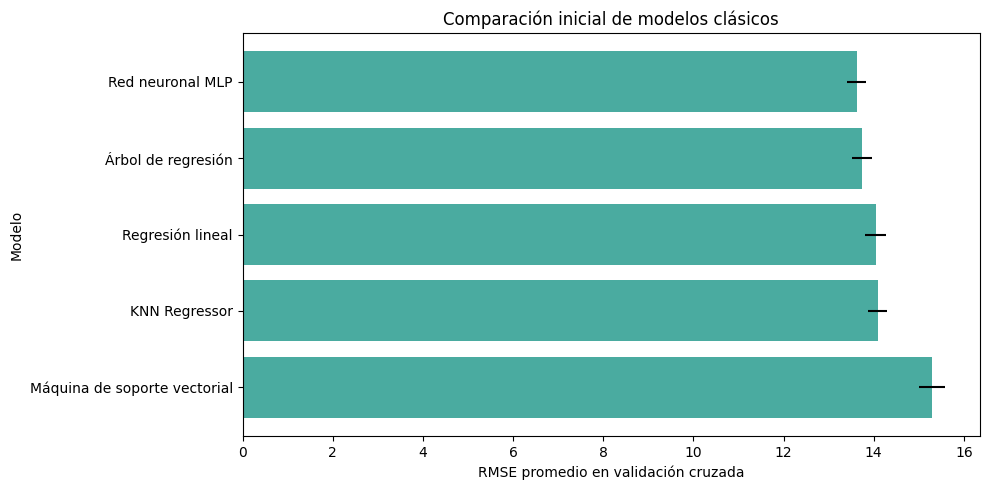

In [18]:
# Comparación visual de los cinco modelos clásicos
tabla_grafica = resultados_clasicos.sort_values("RMSE promedio")

plt.figure(figsize=(10, 5))
plt.barh(
    tabla_grafica["Modelo"],
    tabla_grafica["RMSE promedio"],
    xerr=tabla_grafica["RMSE desviación"],
    color="#2a9d8f",
    alpha=0.85,
)
plt.xlabel("RMSE promedio en validación cruzada")
plt.ylabel("Modelo")
plt.title("Comparación inicial de modelos clásicos")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Modelos de ensamble

Los ensambles combinan varios estimadores con el propósito de obtener predicciones más estables o reducir el error:

- **Votación:** promedia las predicciones de una regresión lineal, un árbol y una máquina de soporte vectorial.
- **Bagging:** entrena varios árboles sobre muestras diferentes del conjunto de entrenamiento y promedia sus resultados.
- **Boosting:** construye árboles de manera secuencial, de modo que cada estimador intenta corregir los errores de los anteriores.

In [19]:
modelo_votacion = VotingRegressor(
    estimators=[
        ("lineal", LinearRegression()),
        (
            "arbol",
            DecisionTreeRegressor(
                max_depth=12,
                min_samples_leaf=5,
                random_state=SEMILLA,
            ),
        ),
        (
            "svr",
            LinearSVR(
                C=1.0,
                epsilon=0.1,
                max_iter=10000,
                random_state=SEMILLA,
            ),
        ),
    ],
)

modelos_ensemble = {
    "Votación": modelo_votacion,
    "Bagging": BaggingRegressor(
        estimator=DecisionTreeRegressor(
            min_samples_leaf=3,
            random_state=SEMILLA,
        ),
        n_estimators=50,
        max_samples=0.80,
        bootstrap=True,
        n_jobs=1,
        random_state=SEMILLA,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.10,
        max_depth=3,
        random_state=SEMILLA,
    ),
}

resultados_ensemble, pipelines_ensemble = evaluar_modelos(
    modelos=modelos_ensemble,
    tipo="Ensamble",
)

display(resultados_ensemble.round(4))

Evaluando: Votación
Evaluando: Bagging
Evaluando: Gradient Boosting


,Tipo,Modelo,RMSE promedio,RMSE desviación,MAE promedio,MAE desviación,R2 promedio,R2 desviación,Tiempo segundos
0,Ensamble,Bagging,13.7139,0.2211,7.1775,0.0667,0.2267,0.0104,213.7281
1,Ensamble,Gradient Boosting,13.7887,0.2265,7.3229,0.0649,0.2183,0.0080,19.8602
2,Ensamble,Votación,13.9833,0.2495,6.9742,0.0727,0.1961,0.0055,4.6174


In [20]:
# Comparación conjunta antes del ajuste de hiperparámetros
resultados_iniciales = (
    pd.concat([resultados_clasicos, resultados_ensemble], ignore_index=True)
    .sort_values("RMSE promedio")
    .reset_index(drop=True)
)

display(resultados_iniciales.round(4))

mejor_inicial = resultados_iniciales.iloc[0]
print("Mejor resultado inicial según RMSE:", mejor_inicial["Modelo"])
print("RMSE promedio:", round(mejor_inicial["RMSE promedio"], 4))
print("Desviación del RMSE:", round(mejor_inicial["RMSE desviación"], 4))

,Tipo,Modelo,RMSE promedio,RMSE desviación,MAE promedio,MAE desviación,R2 promedio,R2 desviación,Tiempo segundos
0,Clásico,Red neuronal MLP,13.6227,0.2142,7.1688,0.0756,0.2370,0.0085,74.7076
1,Ensamble,Bagging,13.7139,0.2211,7.1775,0.0667,0.2267,0.0104,213.7281
2,Clásico,Árbol de regresión,13.7328,0.2250,7.1947,0.0683,0.2246,0.0100,11.7715
3,Ensamble,Gradient Boosting,13.7887,0.2265,7.3229,0.0649,0.2183,0.0080,19.8602
4,Ensamble,Votación,13.9833,0.2495,6.9742,0.0727,0.1961,0.0055,4.6174
5,Clásico,Regresión lineal,14.0404,0.2231,7.6570,0.0686,0.1895,0.0053,6.8625
6,Clásico,KNN Regressor,14.0921,0.2126,7.3985,0.0677,0.1834,0.0140,127.1738
7,Clásico,Máquina de soporte vectorial,15.2900,0.2881,6.6283,0.0951,0.0389,0.0083,2.8238


Mejor resultado inicial según RMSE: Red neuronal MLP
RMSE promedio: 13.6227
Desviación del RMSE: 0.2142


## Ajuste de hiperparámetros

Se ajusta **GradientBoostingRegressor** porque puede representar relaciones no lineales e interacciones entre las variables, y permite estudiar de forma clara el equilibrio entre complejidad y capacidad de aprendizaje. La búsqueda utiliza RMSE como criterio y conserva las mismas 10 particiones del conjunto de entrenamiento.

### Hiperparámetros evaluados

| Hiperparámetro | Qué controla | Rango elegido | Justificación |
|---|---|---|---|
| `n_estimators` | Número de árboles construidos secuencialmente. | 100 y 200 | Permite comparar un ensamble moderado con uno más amplio sin elevar de forma desproporcionada el tiempo de ejecución. |
| `learning_rate` | Contribución de cada árbol al resultado acumulado. | 0.05 y 0.10 | Son tasas conservadoras que permiten evaluar si un aprendizaje más gradual mejora la generalización. |
| `max_depth` | Complejidad de cada árbol base. | 2 y 3 | Estas profundidades permiten modelar interacciones sin construir árboles excesivamente complejos para solo tres variables de entrada. |

La búsqueda contiene ocho combinaciones y realiza diez validaciones por combinación. En total se ejecutan 80 ajustes dentro del conjunto de entrenamiento. El 30 % de prueba sigue sin utilizarse.

In [21]:
pipeline_boosting = construir_pipeline(
    GradientBoostingRegressor(random_state=SEMILLA)
)

grilla_parametros = {
    "modelo__n_estimators": [100, 200],
    "modelo__learning_rate": [0.05, 0.10],
    "modelo__max_depth": [2, 3],
}

busqueda = GridSearchCV(
    estimator=pipeline_boosting,
    param_grid=grilla_parametros,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=N_JOBS,
    refit=True,
    return_train_score=True,
    verbose=1,
)

inicio_ajuste = perf_counter()
busqueda.fit(X_train, y_train)
tiempo_ajuste = perf_counter() - inicio_ajuste

print("Mejores hiperparámetros:", busqueda.best_params_)
print("Mejor RMSE promedio en validación:", round(-busqueda.best_score_, 4))
print("Tiempo total del ajuste en segundos:", round(tiempo_ajuste, 2))

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Mejores hiperparámetros: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 200}
Mejor RMSE promedio en validación: 13.7145
Tiempo total del ajuste en segundos: 221.02


In [22]:
# Resultados completos de la búsqueda
resultados_grid = pd.DataFrame(busqueda.cv_results_)

columnas_resultados_grid = [
    "param_modelo__n_estimators",
    "param_modelo__learning_rate",
    "param_modelo__max_depth",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score",
]

tabla_grid = resultados_grid[columnas_resultados_grid].copy()
tabla_grid["RMSE validación"] = -tabla_grid["mean_test_score"]
tabla_grid["RMSE entrenamiento"] = -tabla_grid["mean_train_score"]
tabla_grid = tabla_grid.sort_values("rank_test_score")

display(
    tabla_grid[
        [
            "param_modelo__n_estimators",
            "param_modelo__learning_rate",
            "param_modelo__max_depth",
            "RMSE entrenamiento",
            "RMSE validación",
            "std_test_score",
            "rank_test_score",
        ]
    ].round(4)
)

,param_modelo__n_estimators,param_modelo__learning_rate,param_modelo__max_depth,RMSE entrenamiento,RMSE validación,std_test_score,rank_test_score
7,200,0.10,3,13.6791,13.7145,0.2263,1
6,100,0.10,3,13.7661,13.7887,0.2265,2
3,200,0.05,3,13.7686,13.7909,0.2268,3
5,200,0.10,2,13.8163,13.8252,0.2212,4
2,100,0.05,3,13.8727,13.8876,0.2271,5
4,100,0.10,2,13.9108,13.9160,0.2271,6
1,200,0.05,2,13.9146,13.9206,0.2288,7
0,100,0.05,2,14.0262,14.0296,0.2286,8


### Interpretación del ajuste

El efecto de cada hiperparámetro debe interpretarse a partir de la tabla anterior:

- Si aumentar `n_estimators` reduce el RMSE de validación, el modelo se beneficia de más etapas de corrección. Si el error deja de mejorar, el aumento solo agrega costo computacional.
- Una tasa `learning_rate` menor produce un aprendizaje más gradual. Su conveniencia depende de si reduce el RMSE de validación al combinarse con un número suficiente de árboles.
- Una mayor `max_depth` permite relaciones más complejas. Si disminuye el error de entrenamiento pero no el de validación, existe una señal de sobreajuste.
- La diferencia entre RMSE de entrenamiento y validación permite revisar la capacidad de generalización del modelo.

In [23]:
# Comparación entre Gradient Boosting inicial y ajustado
fila_boosting_inicial = resultados_iniciales.loc[
    resultados_iniciales["Modelo"] == "Gradient Boosting"
].iloc[0]

comparacion_ajuste = pd.DataFrame(
    {
        "Modelo": ["Gradient Boosting inicial", "Gradient Boosting ajustado"],
        "RMSE promedio CV": [
            fila_boosting_inicial["RMSE promedio"],
            -busqueda.best_score_,
        ],
        "RMSE desviación CV": [
            fila_boosting_inicial["RMSE desviación"],
            resultados_grid.loc[busqueda.best_index_, "std_test_score"],
        ],
    }
)

comparacion_ajuste["Cambio frente al inicial"] = (
    comparacion_ajuste["RMSE promedio CV"]
    - fila_boosting_inicial["RMSE promedio"]
)

display(comparacion_ajuste.round(4))

rmse_ajustado = -busqueda.best_score_
rmse_mejor_inicial = mejor_inicial["RMSE promedio"]

if rmse_ajustado < rmse_mejor_inicial:
    print("El Gradient Boosting ajustado supera al mejor modelo de la comparación inicial.")
else:
    diferencia = rmse_ajustado - rmse_mejor_inicial
    print(
        "El ajuste mejora Gradient Boosting, pero no supera al mejor modelo inicial. "
        f"La diferencia de RMSE es {diferencia:.4f}."
    )

,Modelo,RMSE promedio CV,RMSE desviación CV,Cambio frente al inicial
0,Gradient Boosting inicial,13.7887,0.2265,0.0000
1,Gradient Boosting ajustado,13.7145,0.2263,-0.0741


El ajuste mejora Gradient Boosting, pero no supera al mejor modelo inicial. La diferencia de RMSE es 0.0918.


## Ajuste de hiperparámetros de la red neuronal

La red neuronal MLP obtuvo el menor RMSE en la comparación inicial, por lo que también se ajusta antes de definir los candidatos que pasarán a la evaluación final. Se utiliza una grilla pequeña para conservar un tiempo de ejecución razonable y mantener la validación cruzada de 10 particiones sobre el conjunto de entrenamiento.

| Hiperparámetro | Qué controla | Valores evaluados | Justificación |
|---|---|---|---|
| `hidden_layer_sizes` | Cantidad de neuronas y estructura de las capas ocultas. | `(32,)` y `(64,)` | Se compara la arquitectura inicial con una capa de mayor capacidad, sin aumentar innecesariamente la complejidad de la red. |
| `alpha` | Intensidad de la regularización L2 aplicada a los pesos. | 0.0001 y 0.001 | Se evalúa la penalización inicial y una alternativa más fuerte para revisar si mejora la generalización. |

La grilla contiene cuatro combinaciones. Con diez particiones se realizan 40 ajustes. La configuración inicial de la MLP está incluida, lo que permite establecer si la búsqueda encuentra una alternativa mejor bajo el mismo procedimiento de validación.

In [24]:
pipeline_mlp = construir_pipeline(
    MLPRegressor(
        activation="relu",
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=SEMILLA,
    )
)

grilla_mlp = {
    "modelo__hidden_layer_sizes": [(32,), (64,)],
    "modelo__alpha": [0.0001, 0.001],
}

busqueda_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=grilla_mlp,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=N_JOBS,
    refit=True,
    return_train_score=True,
    verbose=1,
)

inicio_ajuste_mlp = perf_counter()
busqueda_mlp.fit(X_train, y_train)
tiempo_ajuste_mlp = perf_counter() - inicio_ajuste_mlp

print("Mejores hiperparámetros de la MLP:", busqueda_mlp.best_params_)
print("Mejor RMSE promedio en validación:", round(-busqueda_mlp.best_score_, 4))
print("Tiempo total del ajuste en segundos:", round(tiempo_ajuste_mlp, 2))

Fitting 10 folds for each of 4 candidates, totalling 40 fits
Mejores hiperparámetros de la MLP: {'modelo__alpha': 0.001, 'modelo__hidden_layer_sizes': (64,)}
Mejor RMSE promedio en validación: 13.6213
Tiempo total del ajuste en segundos: 299.83


### Interpretación del ajuste de la red neuronal MLP

La mejor configuración utilizó una capa oculta de 64 neuronas y un valor de `alpha` igual a 0,001. Con esta combinación, el RMSE promedio de validación pasó de 13,6227 a 13,6213. La reducción fue de aproximadamente 0,0014, por lo que el ajuste representa una mejora mínima frente a la configuración inicial.

El RMSE de entrenamiento fue 13,5716 y el de validación 13,6213. La cercanía entre ambos valores no evidencia una diferencia marcada entre el ajuste y la capacidad de generalización. Además, la desviación del RMSE fue 0,2165, ampliamente superior a la mejora obtenida. Por esta razón, los resultados no permiten afirmar que el aumento de la red produzca una ventaja relevante. La configuración ajustada se conserva como candidata y su conveniencia se comprobará con el conjunto de prueba en el punto 5.

In [25]:
# Comparación de los principales candidatos después de los ajustes
fila_mlp_inicial = resultados_iniciales.loc[
    resultados_iniciales["Modelo"] == "Red neuronal MLP"
].iloc[0]

fila_boosting_inicial = resultados_iniciales.loc[
    resultados_iniciales["Modelo"] == "Gradient Boosting"
].iloc[0]

desviacion_mlp_ajustada = busqueda_mlp.cv_results_[
    "std_test_score"
][busqueda_mlp.best_index_]

desviacion_boosting_ajustado = busqueda.cv_results_[
    "std_test_score"
][busqueda.best_index_]

comparacion_candidatos_cv = pd.DataFrame(
    {
        "Modelo": [
            "MLP inicial",
            "MLP ajustada",
            "Gradient Boosting inicial",
            "Gradient Boosting ajustado",
        ],
        "RMSE promedio CV": [
            fila_mlp_inicial["RMSE promedio"],
            -busqueda_mlp.best_score_,
            fila_boosting_inicial["RMSE promedio"],
            -busqueda.best_score_,
        ],
        "RMSE desviación CV": [
            fila_mlp_inicial["RMSE desviación"],
            desviacion_mlp_ajustada,
            fila_boosting_inicial["RMSE desviación"],
            desviacion_boosting_ajustado,
        ],
    }
).sort_values("RMSE promedio CV").reset_index(drop=True)

display(comparacion_candidatos_cv.round(4))

mejor_candidato_cv = comparacion_candidatos_cv.iloc[0]

print(
    "Mejor candidato después de los ajustes:",
    mejor_candidato_cv["Modelo"]
)
print(
    "RMSE promedio:",
    round(mejor_candidato_cv["RMSE promedio CV"], 4)
)
print(
    "La selección definitiva se realizará "
    "con el conjunto de prueba en el punto 5."
)

,Modelo,RMSE promedio CV,RMSE desviación CV
0,MLP ajustada,13.6213,0.2165
1,MLP inicial,13.6227,0.2142
2,Gradient Boosting ajustado,13.7145,0.2263
3,Gradient Boosting inicial,13.7887,0.2265


Mejor candidato después de los ajustes: MLP ajustada
RMSE promedio: 13.6213
La selección definitiva se realizará con el conjunto de prueba en el punto 5.


## Cierre del modelamiento

En esta etapa se compararon cinco modelos clásicos y tres modelos de ensamble mediante el mismo procedimiento de validación cruzada. La comparación consideró el RMSE promedio, su desviación, las métricas complementarias y el tiempo de ejecución.

El ajuste de Gradient Boosting redujo su RMSE de 13,7887 a 13,7145. En la red neuronal MLP, la mejor configuración utilizó 64 neuronas y `alpha=0,001`, con un RMSE de 13,6213 frente a 13,6227 de la configuración inicial. La mejora de la MLP fue mínima, lo que indica que su desempeño inicial ya era estable dentro del rango evaluado.

La búsqueda de hiperparámetros permite mejorar cada algoritmo dentro de las configuraciones consideradas, aunque la magnitud del cambio también debe analizarse. **La MLP ajustada, la MLP inicial y Gradient Boosting ajustado pasan como candidatos al punto 5**. Allí serán evaluados con el 30 % reservado para tomar la decisión final con datos que no intervinieron en el entrenamiento ni en la selección de hiperparámetros.

# Evaluación

En esta etapa se evaluarán los principales modelos seleccionados durante la fase de modelamiento utilizando el conjunto de prueba reservado previamente.

La evaluación se realizará mediante RMSE, MAE y R². El RMSE se mantiene como métrica principal para seleccionar el modelo final, mientras que MAE y R² se utilizarán como métricas complementarias.

El conjunto de prueba no participó en el entrenamiento, la validación cruzada ni el ajuste de hiperparámetros, por lo que permite evaluar el comportamiento de los modelos frente a datos no utilizados durante las etapas anteriores.

In [26]:
# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Entrenar la MLP inicial con todo el conjunto de entrenamiento
mlp_inicial = pipelines_clasicos["Red neuronal MLP"]
mlp_inicial.fit(X_train, y_train)

# Modelos que pasan a la evaluación final
candidatos_finales = {
    "MLP inicial": mlp_inicial,
    "MLP ajustada": busqueda_mlp.best_estimator_,
    "Gradient Boosting ajustado": busqueda.best_estimator_
}

resultados_prueba = []

# Evaluar cada modelo con el conjunto de prueba
for nombre, modelo in candidatos_finales.items():

    # Realizar predicciones
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados_prueba.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Crear tabla de resultados
resultados_prueba = pd.DataFrame(resultados_prueba)

# Ordenar de mejor a peor según RMSE
resultados_prueba = resultados_prueba.sort_values(
    "RMSE"
).reset_index(drop=True)

display(resultados_prueba.round(4))

,Modelo,MAE,RMSE,R2
0,MLP inicial,7.1455,13.4981,0.2433
1,MLP ajustada,7.1025,13.5062,0.2424
2,Gradient Boosting ajustado,7.2412,13.6061,0.2312


## Análisis de los resultados en prueba

Los resultados obtenidos en el conjunto de prueba muestran que los dos modelos MLP presentan un desempeño muy similar. La MLP inicial obtuvo el menor RMSE con 13.4981 y el mayor R² con 0.2433. Por su parte, la MLP ajustada alcanzó el menor MAE con 7.1025.

El modelo Gradient Boosting ajustado presentó un desempeño ligeramente inferior, con un RMSE de 13.6061, un MAE de 7.2412 y un R² de 0.2312.

Debido a que el RMSE fue definido como la métrica principal desde el inicio del proyecto, la MLP inicial presenta el mejor resultado en el conjunto de prueba. Aunque la MLP ajustada logró un MAE ligeramente menor, el ajuste de hiperparámetros no permitió superar a la configuración inicial en la métrica principal.

Estos resultados serán comparados con los obtenidos durante la validación cruzada para verificar la estabilidad y capacidad de generalización de los modelos antes de seleccionar el modelo final.